#Practica de Redes Neuronales
##Dataset:
- Wholesale customers data
##Estudiantes:
- Luis Ernesto Jaldin Merida
- Jhaddyn Brian Ortiz Alanoca

# Paso 1. Importar las librerías

In [10]:
# Manejo de datos
import pandas as pd
import numpy as np

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TensorFlow y Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Visualización
import matplotlib.pyplot as plt

# Paso 2. Cargar el dataset

In [11]:
# Cargar el dataset
df = pd.read_csv('/Wholesale customers data.csv')

# Mostrar las primeras filas
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# Paso 3. Exploración del dataset

In [12]:
# Dimensiones del dataset
print('Dimensiones del dataset:')
print(df.shape)

# Información general
print('\nInformación del dataset:')
print(df.info())

# Estadísticas descriptivas
print('\nEstadísticas descriptivas:')
print(df.describe())

# Valores nulos
print('\nValores nulos por columna:')
print(df.isnull().sum())

# Distribución de la variable objetivo
print('\nDistribución de la variable Channel:')
print(df['Channel'].value_counts())

Dimensiones del dataset:
(440, 8)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

Estadísticas descriptivas:
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1

# Paso 4. Preparación de los datos

In [13]:
# Variables de entrada (X) y variable objetivo (y)
X = df.drop('Channel', axis=1)
y = df['Channel']

# Convertir las clases de Channel de (1,2) a (0,1)
y = df['Channel'].map({
    1: 0,
    2: 1
})

# Mostrar las dimensiones
print('Dimensiones de X:', X.shape)
print('Dimensiones de y:', y.shape)

# Primeras filas de X
print('\nPrimeras filas de X:')
print(X.head())

# Primeros valores de y
print('\nPrimeros valores de y:')
print(y.head())

Dimensiones de X: (440, 7)
Dimensiones de y: (440,)

Primeras filas de X:
   Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0       3  12669  9656     7561     214              2674        1338
1       3   7057  9810     9568    1762              3293        1776
2       3   6353  8808     7684    2405              3516        7844
3       3  13265  1196     4221    6404               507        1788
4       3  22615  5410     7198    3915              1777        5185

Primeros valores de y:
0    1
1    1
2    1
3    0
4    1
Name: Channel, dtype: int64


# Paso 5. División del dataset y normalización

In [14]:
# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Crear el escalador
scaler = StandardScaler()

# Ajustar el escalador con los datos de entrenamiento
X_train = scaler.fit_transform(X_train)

# Transformar los datos de prueba
X_test = scaler.transform(X_test)

# Mostrar dimensiones
print('Datos de entrenamiento:')
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('\nDatos de prueba:')
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

Datos de entrenamiento:
X_train: (352, 7)
y_train: (352,)

Datos de prueba:
X_test: (88, 7)
y_test: (88,)


# Paso 6. Construcción de la red neuronal

In [15]:
# Crear el modelo de red neuronal
modelo = Sequential()

# Capa de entrada y primera capa oculta
modelo.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Segunda capa oculta
modelo.add(Dense(8, activation='relu'))

# Capa de salida
modelo.add(Dense(1, activation='sigmoid'))

# Mostrar la arquitectura del modelo
modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

# Paso 7. Compilación y entrenamiento de la red neuronal

In [16]:
# Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo
historial = modelo.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6548 - loss: 0.6249 - val_accuracy: 0.6761 - val_loss: 0.6365
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7473 - loss: 0.5962 - val_accuracy: 0.8028 - val_loss: 0.6041
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8363 - loss: 0.5675 - val_accuracy: 0.9014 - val_loss: 0.5735
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8541 - loss: 0.5413 - val_accuracy: 0.9014 - val_loss: 0.5449
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8577 - loss: 0.5170 - val_accuracy: 0.9014 - val_loss: 0.5186
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8505 - loss: 0.4941 - val_accuracy: 0.9014 - val_loss: 0.4934
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8541 - loss: 0.4734 - val_accuracy: 0.9014 - val_loss: 0.4690
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8541 - loss: 0.4540 - val_accuracy: 0.9014 - val_loss: 0.4446


# Paso 8. Visualización del entrenamiento

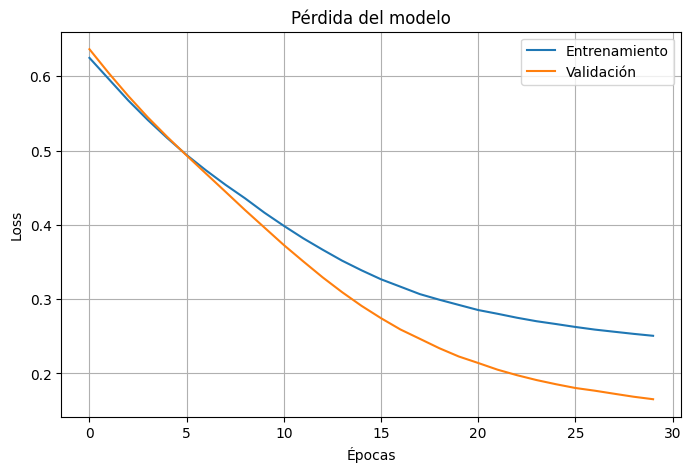

In [17]:
# Graficar la pérdida (Loss)
plt.figure(figsize=(8,5))
plt.plot(historial.history['loss'], label='Entrenamiento')
plt.plot(historial.history['val_loss'], label='Validación')

plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# Paso 9. Evaluación del modelo

In [18]:
# Evaluar el modelo con el conjunto de prueba
loss, accuracy = modelo.evaluate(X_test, y_test, verbose=0)

print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

Pérdida (Loss): 0.2710
Precisión (Accuracy): 0.9091


# Paso 10. Realizar predicciones con el modelo

In [19]:
# Realizar predicciones sobre el conjunto de prueba
predicciones = modelo.predict(X_test)

# Convertir probabilidades a clases (0 o 1)
predicciones_clase = (predicciones > 0.5).astype(int)

# Mostrar algunas predicciones
print("Valor real | Valor predicho")

for i in range(10):
    print(f"{y_test.iloc[i]} \t\t {predicciones_clase[i][0]}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Valor real | Valor predicho
0 		 1
0 		 0
1 		 1
0 		 0
0 		 0
0 		 0
0 		 0
1 		 1
0 		 0
0 		 0


##(Opcional) Paso 11. Matriz de Confusion

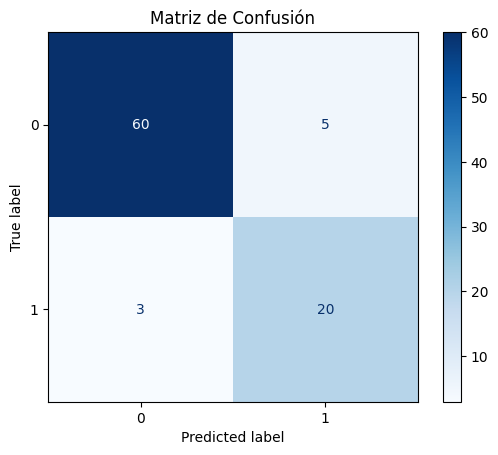

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de confusión
cm = confusion_matrix(y_test, predicciones_clase)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.show()